# Principal Component Analysis (PCA)

<details>
<summary><strong>What is PCA?</strong></summary>

Principal Component Analysis (PCA) is an **unsupervised dimensionality reduction** technique.

It transforms the original features into a smaller set of **principal components** while preserving as much information (variance) as possible.

</details>

---

<details>
<summary><strong>Why Use PCA?</strong></summary>

- Reduce the number of features.
- Remove redundant information.
- Speed up model training.
- Reduce overfitting.
- Visualize high-dimensional data in 2D or 3D.

</details>

---

<details>
<summary><strong>How Does PCA Work?</strong></summary>

1. Standardize the data.
2. Find the directions with the highest variance.
3. Create new features called **Principal Components (PCs)**.
4. Keep the most important components and discard the rest.

</details>

---

<details>
<summary><strong>Principal Components</strong></summary>

- **PC1:** Captures the largest amount of variance.
- **PC2:** Captures the second largest variance and is perpendicular to PC1.
- Additional components capture the remaining variance.

</details>

---

<details>
<summary><strong>Example</strong></summary>

Original Features:

```text
Age
Income
Education
Experience
```

After PCA:

```text
PC1
PC2
```

The dataset now has **2 features instead of 4** while retaining most of the information.

</details>

---

<details>
<summary><strong>Advantages</strong></summary>

- Reduces dimensionality.
- Faster training.
- Removes correlated features.
- Helps visualize data.
- Can improve model performance.

</details>

---

<details>
<summary><strong>Disadvantages</strong></summary>

- New features are harder to interpret.
- Some information is lost.
- Requires feature scaling.

</details>

---

<details>
<summary><strong>Summary</strong></summary>

- Unsupervised learning technique.
- Used for **dimensionality reduction**.
- Creates new features called **Principal Components**.
- Preserves the maximum possible variance.
- Requires feature scaling before applying PCA.

</details>

In [30]:
import numpy as np
from sklearn import decomposition
from sklearn import datasets

In [31]:
iris=datasets.load_iris()
x=iris.data
print("Features Values : \n",x)

Features Values : 
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4

In [32]:
y=iris.target
print("Target Values :\n",y)

Target Values :
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x = scaler.fit_transform(x)

In [34]:
x.shape
print("Features Before PCA : \n",x[:10])

Features Before PCA : 
 [[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]
 [-0.53717756  1.93979142 -1.16971425 -1.05217993]
 [-1.50652052  0.78880759 -1.34022653 -1.18381211]
 [-1.02184904  0.78880759 -1.2833891  -1.3154443 ]
 [-1.74885626 -0.36217625 -1.34022653 -1.3154443 ]
 [-1.14301691  0.09821729 -1.2833891  -1.44707648]]


In [35]:
# Reduce my dataset to 2 principal components.
# instead of 4 features pca make them 2

# Create two entirely new features
pca =decomposition.PCA(n_components=2)
pca.fit(x)
x=pca.transform(x)

print(x.shape)
print("PC1 : \n",x[:10,0])
print("\nPC2 : \n",x[:10,1])

(150, 2)
PC1 : 
 [-2.26470281 -2.08096115 -2.36422905 -2.29938422 -2.38984217 -2.07563095
 -2.44402884 -2.23284716 -2.33464048 -2.18432817]

PC2 : 
 [ 0.4800266  -0.67413356 -0.34190802 -0.59739451  0.64683538  1.48917752
  0.0476442   0.22314807 -1.11532768 -0.46901356]


Text(0.5, 1.0, 'PCA Projection')

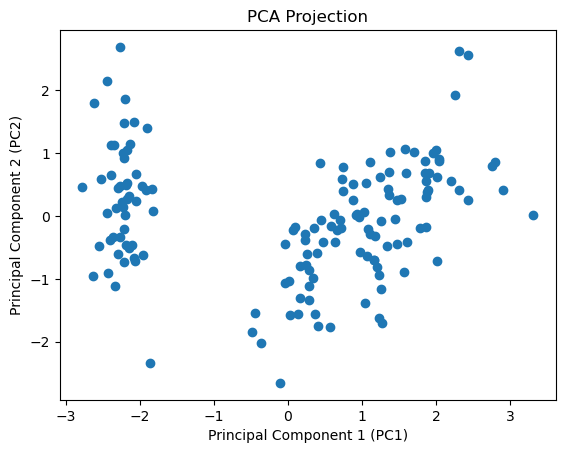

In [39]:
# Now We can visualize features in 2D figure
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1])

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA Projection")